## **Luchesini Lorenzo - 881345**

In [ ]:
%pip install pennylane numpy pandas matplotlib

## **0. Core Module**

In [ ]:
import math
from dataclasses import dataclass, asdict
from fractions import Fraction

import numpy as np
import pennylane as qml


# ======================================================================
#  We define the later imports for our experiment
# ======================================================================
__all__ = [
    "multiplicative_order",
    "n_target_qubits",
    "continued_fraction_convergents",
    "modmul_permutation",
    "modmul_matrix",
    "modmul_gate",
    "inverse_qft",
    "swap_network_mod15",
    "order_finding_circuit",
    "order_finding_probs",
    "phase_to_order",
    "factor_from_phase",
    "SweepPoint",
    "analyse",
]


# ======================================================================
#  Number-theory helpers (all classical, no quantum here)
# ======================================================================
def multiplicative_order(a, N):
    """
    Smallest r > 0 such that a**r % N == 1 (the order of a mod N).
    Computed by repeated multiplication, fine for small N used here.
    """
    if math.gcd(a, N) != 1:
        raise ValueError(f"gcd({a}, {N}) = {math.gcd(a, N)} != 1")
    r, x = 1, a % N
    while x != 1:
        x = (x * a) % N
        r += 1
    return r


def n_target_qubits(N):
    """
    Number of qubits needed to store the values 0 .. N-1.
    Equivalent to the IBM tutorial's floor(log2(N - 1)) + 1.
    """
    return max(1, (N - 1).bit_length())


def continued_fraction_convergents(x, max_denominator):
    """
    Convergents p/q of the continued-fraction expansion of x with
    q <= max_denominator, returned as a list of (p, q) tuples.
    This is the exact procedure referred to in the theory; :func: phase_to_order
    uses the equivalent Fraction.limit_denominator shortcut.
    """
    convergents = []
    h_prev, h_cur = 1, math.floor(x) # p, math.floor(x) = a_0
    k_prev, k_cur = 0, 1 # q
    convergents.append((h_cur, k_cur))
    frac = x - math.floor(x)
    while frac > 1e-12:
        x = 1.0 / frac
        ai = math.floor(x)
        h_prev, h_cur = h_cur, ai * h_cur + h_prev # recursive conditions in the succession of convergents
        k_prev, k_cur = k_cur, ai * k_cur + k_prev
        if k_cur > max_denominator:
            break
        convergents.append((h_cur, k_cur)) # the last duple of terms of this succession are the goal
        frac = x - ai
    return convergents


# ======================================================================
#  Modular-multiplication operator M_b
# ======================================================================
def modmul_permutation(b, N, n):
    """
    Permutation array p of length 2**n with p[x] = (b*x) % N for
    x < N and p[x] = x otherwise.
    Because gcd(b, N) = 1, the map x -> b*x mod N is a bijection of {0, .., N-1}; #b is a here and its powers
    the states {N, .., 2**n - 1} are left untouched.
    """
    if math.gcd(b, N) != 1:
        raise ValueError(f"gcd({b}, {N}) != 1, x -> b*x mod N is not invertible")
    dim = 1 << n # this is 2^n
    perm = np.arange(dim) # this is (0, 1, ..., 2^(n-1))
    for x in range(N):
        perm[x] = (b * x) % N
    return perm


def modmul_matrix(b, N, n):
    """
    Dense 2**n x 2**n permutation matrix of M_b (so that U|x> = |p[x]>).
    We build the matrix explicitly and feed it to qml.QubitUnitary.  This is
    the general construction used for N = 21, 35, 105; for n <= 7 the matrix is at
    most 128 x 128, so it is cheap for the simulator.
    """
    perm = modmul_permutation(b, N, n)
    dim = 1 << n
    U = np.zeros((dim, dim))
    U[perm, np.arange(dim)] = 1.0 # U[landing, starting]
    return U


def modmul_gate(b, N, n, wires):
    """
    Apply M_b on wires as a single qml.QubitUnitary.
    Note on resource accounting: the quantity that matters for the spatial-cost
    study is the number of controlled-M_b calls (= t) and the counting-register
    QFT, not the internal gate count of one M_b (which does not depend on t and,
    for the special (N, a) used here, is a handful of SWAPs anyway).
    """
    return qml.QubitUnitary(modmul_matrix(b, N, n), wires=wires)


def swap_network_mod15(b, wires):
    """
    Hand-written SWAP network for M_b (mod 15) with b in {1, 2, 4, 8},
    exactly as in the IBM tutorial.
    Multiplication by 2 modulo 15 = 2**4 - 1 is a cyclic shift of the 4 target
    bits, hence a product of SWAP gates. Used only to reproduce the tutorial for
    N = 15; :func: modmul_gate is the general path.
    """
    w = list(wires)
    if len(w) != 4:
        raise ValueError("swap_network_mod15 needs exactly 4 target wires")
    if b == 2:
        qml.SWAP(wires=[w[2], w[3]])
        qml.SWAP(wires=[w[1], w[2]])
        qml.SWAP(wires=[w[0], w[1]])
    elif b == 4:
        qml.SWAP(wires=[w[1], w[3]])
        qml.SWAP(wires=[w[0], w[2]])
    elif b == 8:
        qml.SWAP(wires=[w[0], w[1]])
        qml.SWAP(wires=[w[1], w[2]])
        qml.SWAP(wires=[w[2], w[3]])
    elif b == 1:
        pass  # M_1 is the identity
    else:
        raise ValueError(f"no SWAP network hard-coded for b = {b} (mod 15)")


# ======================================================================
#  Inverse QFT and the order-finding circuit (manual QPE, tunable t)
# ======================================================================
def inverse_qft(wires):
    """
    Inverse QFT built from elementary gates only: H, controlled phase shifts,
    and SWAPs.
    Why not qml.adjoint(qml.QFT): that operation asks the simulator for a
    dense 2**t x 2**t matrix, which runs out of memory around t = 13-15.
    Expanding the transform into O(t^2) two-qubit gates keeps every step small.
    Matches qml.QFT (first wire = most significant bit).
    """
    wires = list(wires)
    m = len(wires)
    for i in range(m // 2):  # undo the wire reversal that ends a forward QFT
        qml.SWAP(wires=[wires[i], wires[m - 1 - i]])
    for j in reversed(range(m)):
        for k in reversed(range(j + 1, m)):
            qml.ControlledPhaseShift(-np.pi / 2 ** (k - j),
                                     wires=[wires[k], wires[j]])
        qml.Hadamard(wires=wires[j])


def _apply_order_finding(N, a, t, n, use_swap_network, qft_as_block=False):
    """
    Gate body of the order-finding circuit.
    Wires 0 .. t-1 are the counting register C, wires t .. t+n-1 are the target
    register T.
    qft_as_block keeps the inverse QFT as a single opaque box -- only for
    drawing; it would materialise a 2**t matrix if actually executed.
    """
    C = list(range(t))
    T = list(range(t, t + n))
    qml.PauliX(wires=T[-1])  # 1) Target register initialised to |1> (MSB-first, so value 1 = X on T[-1])
    for j in range(t):  # 2) Hadamard layer on the counting register
        qml.Hadamard(wires=C[j])
    for j in range(t):  # 3) Controlled modular exponentiation. Counting qubit C[j] has weight 2**j, so it drives  M_a^(2**j) = M_b  with  b = a**(2**j) mod N.
        b = pow(a, 1 << j, N)
        if b == 1:  # M_1 is the identity -- skip, like IBM tutorial does
            continue
        if use_swap_network:
            qml.ctrl(swap_network_mod15, control=C[j])(b, T)
        else:
            qml.ctrl(modmul_gate, control=C[j])(b, N, n, T)
    if qft_as_block: # 4) Inverse QFT on the counting register.  C[j] has weight 2**j (C[0] = LSB), while the QFT convention treats its first wire as the MSB -> pass C[::-1].
        qml.adjoint(qml.QFT)(wires=C[::-1])
    else:
        inverse_qft(C[::-1]) # with :: we consider [0.....(t]-1)


def order_finding_circuit(N, a, t, n=None, use_swap_network=False,
                          device_name="default.qubit", qft_as_block=False):
    """
    Return a QNode that outputs qml.probs of the counting register.
    Parameters
    ----------
    N, a : the number to factor and the base (must be coprime).
    t    : number of counting qubits -- the knob of the whole experiment.
    n    : target-register size; defaults to n_target_qubits(N).
    use_swap_network : use the hand-written mod-15 SWAP network instead of
                       QubitUnitary (only valid for N = 15).
    qft_as_block     : draw the inverse QFT as one box (drawing only).
    """
    n = n or n_target_qubits(N)
    C = list(range(t))
    dev = qml.device(device_name, wires=t + n)
    @qml.qnode(dev)
    def circuit():
        _apply_order_finding(N, a, t, n, use_swap_network, qft_as_block) # read C back in weight order (C[0] = LSB) -> integer y, phase = y / 2**t
        return qml.probs(wires=C[::-1])
    return circuit


def order_finding_probs(N, a, t, n=None, use_swap_network=False,
                        device_name="default.qubit"):
    """
    Exact probability vector (length 2**t) over the counting register.
    Entry y is the probability of measuring the integer y, i.e. of the
    phase estimate y / 2**t.
    """
    return np.asarray(
        order_finding_circuit(N, a, t, n, use_swap_network, device_name)()
    )


# ======================================================================
#  Classical post-processing (continued fractions -> order -> factor)
# ======================================================================
def phase_to_order(phase, N, a, max_denominator=None):
    """
    Recover a candidate order r from a measured phase, or None.
    Fraction(phase).limit_denominator(N-1) is the best rational approximation
    with denominator < N; its denominator is the first order guess.  The true
    order can be a small multiple of it, so we test multiples until a^r = 1.
    """
    if phase <= 0.0:
        return None
    max_denominator = max_denominator if max_denominator is not None else N - 1
    q = Fraction(phase).limit_denominator(max_denominator).denominator
    if q == 0:
        return None
    for m in range(1, N // q + 1):
        r = m * q # here is the lucky recover from N= 35, 105!
        if pow(a, r, N) == 1:
            return r
    return None


def factor_from_phase(phase, N, a):
    """
    Full single-shot Shor post-processing: return a non-trivial factor of
    N, or None if this measurement outcome fails.
    Fails when: phase = 0; the recovered order is odd; or a^(r/2) = -1 (mod N),
    which carries no information. Otherwise gcd(a^(r/2) +- 1, N) is a factor.
    """
    r = phase_to_order(phase, N, a)
    if r is None or r % 2 != 0:
        return None
    x = pow(a, r // 2, N)
    if x == N - 1:  # a^(r/2) == -1 (mod N)
        return None
    for cand in (math.gcd(x - 1, N), math.gcd(x + 1, N)):
        if 1 < cand < N:
            return cand
    return None


# ======================================================================
#  Experiment: all metrics for one (N, a, t) point
# ======================================================================
@dataclass
class SweepPoint:
    N: int
    a: int
    r: int
    n: int
    t: int
    width: int                   # total qubits = t + n
    n_ctrl_mult: int             # nominal controlled-M_b calls (= t)
    n_ctrl_mult_nontrivial: int  # calls with b != 1 (the modular-arithmetic cost)
    qft_ctrl_phase: int          # controlled-phase gates in the inverse QFT = t(t-1)/2
    p_resolve: float             # P[ measured phase within 1/(2 r^2) of some k/r ]
    p_resolve_worstcase: float   # same, tolerance 1/(2 N^2)  (r-agnostic bound)
    p_factor: float              # P[ one shot yields a non-trivial factor of N ]
    expected_shots: float        # 1 / p_factor  (inf if p_factor == 0)
    def as_dict(self):
        return asdict(self)


def analyse(N, a, t, n=None, probs=None, use_swap_network=False):
    """
    Compute every metric of the QPE-register experiment for one (N, a, t).
    P_resolve is a purely spatial metric: "did the counting register have enough
    bits to place the phase within continued-fraction range of a true k/r?".
    P_factor is the end-to-end single-shot success probability; the gap between
    the two is the fixed number-theoretic overhead (theory notes: success
    probability >= 1 - 2^-(k-1), k = number of distinct prime factors).
    """
    n = n or n_target_qubits(N)
    r = multiplicative_order(a, N)
    if probs is None:
        probs = order_finding_probs(N, a, t, n, use_swap_network)
    probs = np.asarray(probs)
    dim = probs.size # 2**t
    phases = np.arange(dim) / dim

    # --- P_resolve: is the measured phase close enough to some k/r? ---------
    def _resolve_prob(tol):
        ks = np.arange(max(r, 1))
        d = np.abs(phases[:, None] - (ks / r)[None, :])
        d = np.minimum(d, 1.0 - d) # distance on the unit circle
        return float(probs[d.min(axis=1) < tol].sum())

    p_resolve = _resolve_prob(1.0 / (2 * r * r))
    p_resolve_wc = _resolve_prob(1.0 / (2 * N * N))

    # --- P_factor: run the full classical post-processing on every outcome --
    factor_mask = np.fromiter(
        (factor_from_phase(p, N, a) is not None for p in phases),
        dtype=bool, count=dim,
    )
    p_factor = float(probs[factor_mask].sum())

    # --- circuit-resource counters ----------------------------------------
    b_list = [pow(a, 1 << j, N) for j in range(t)]
    n_nontrivial = sum(b != 1 for b in b_list)
    qft_ctrl_phase = t * (t - 1) // 2

    return SweepPoint(
        N=N, a=a, r=r, n=n, t=t,
        width=t + n,
        n_ctrl_mult=t,
        n_ctrl_mult_nontrivial=n_nontrivial,
        qft_ctrl_phase=qft_ctrl_phase,
        p_resolve=p_resolve,
        p_resolve_worstcase=p_resolve_wc,
        p_factor=p_factor,
        expected_shots=(1.0 / p_factor) if p_factor > 0 else math.inf,
    )


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fractions import Fraction

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.dpi"] = 120
COLORS = {15: "#4C72B0", 21: "#DD8452", 35: "#55A868", 105: "#C44E52"}

## **1. Validation on $N = 15$**

For $N = 15$ we reproduce the IBM tutorial: $a = 2$, $t = 8$, and the $M_b$
realised as a **SWAP network**, multiplying by 2 mod 15 is a cyclic 4-bit shift.

N=15, a=2, t=8, n=4, order r = 4


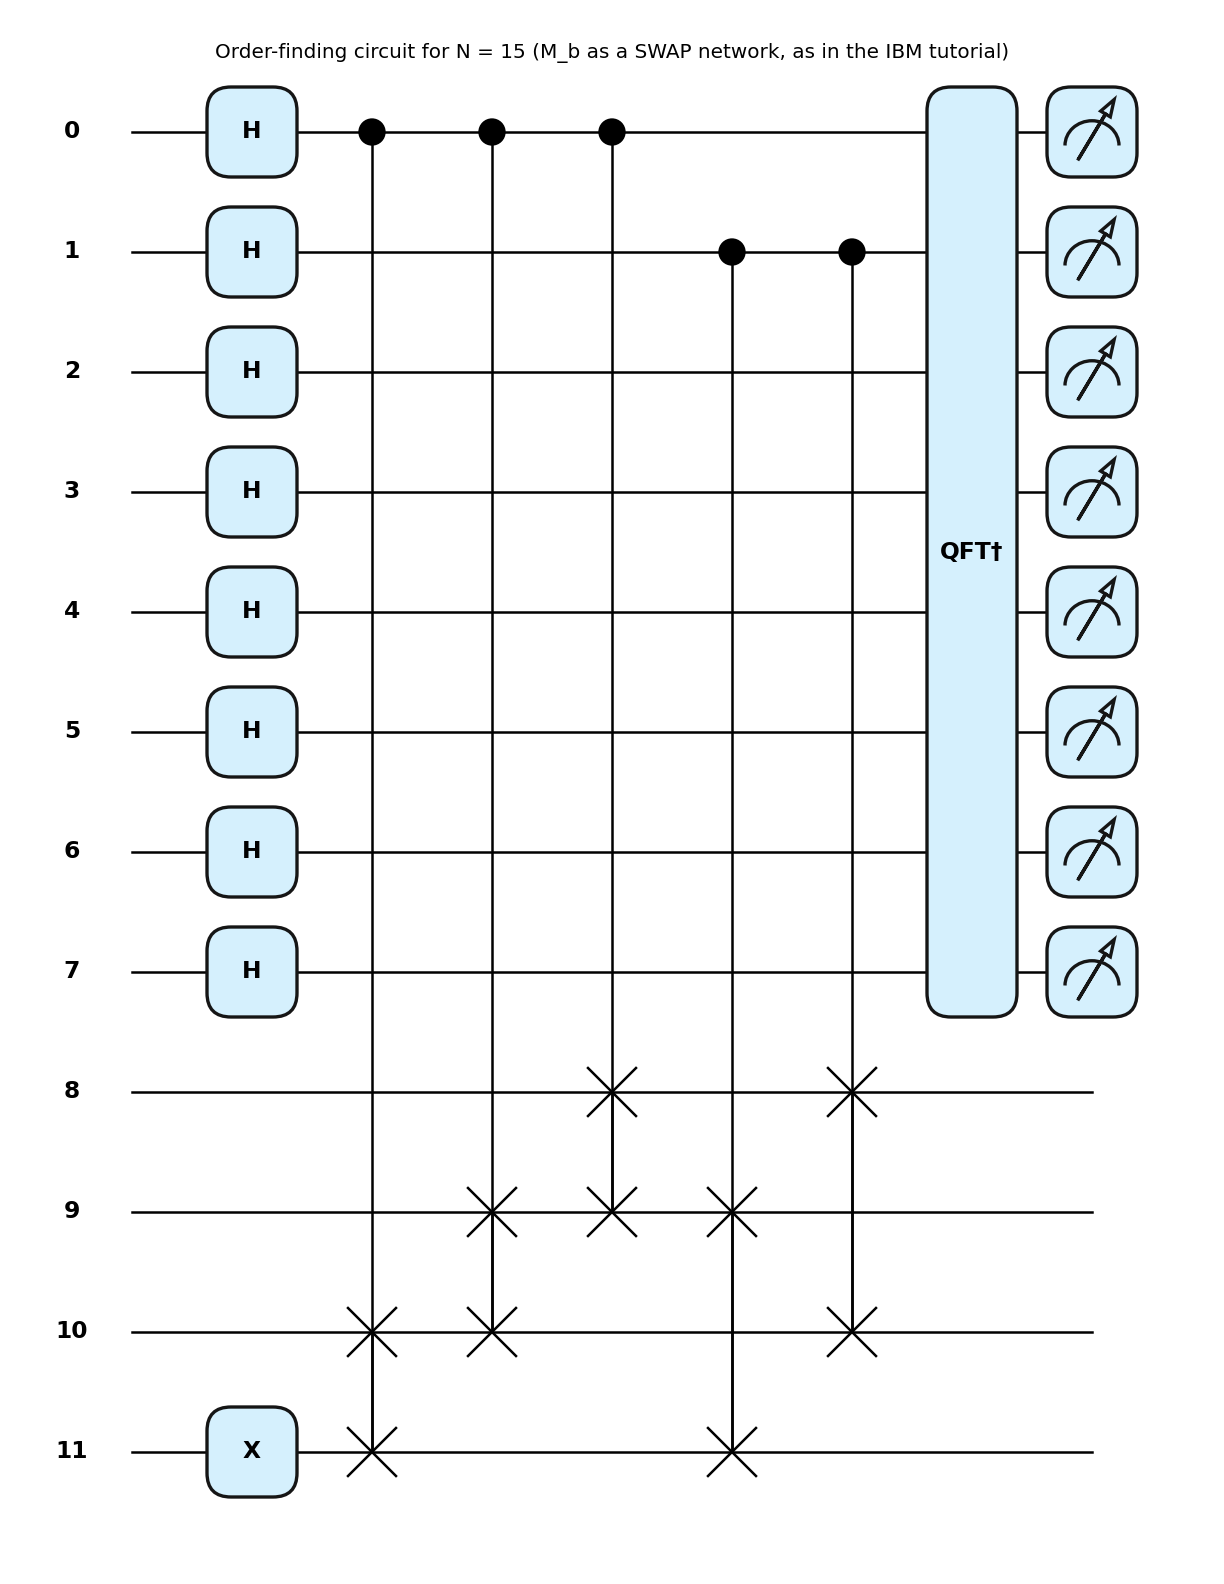

0: ──H─╭●────╭●────╭●────────────────╭QFT†─┤ ╭Probs
1: ──H─│─────│─────│─────╭●────╭●────├QFT†─┤ ├Probs
2: ──H─│─────│─────│─────│─────│─────├QFT†─┤ ├Probs
3: ──H─│─────│─────│─────│─────│─────╰QFT†─┤ ╰Probs
4: ────│─────│─────├SWAP─│─────├SWAP───────┤       
5: ────│─────├SWAP─╰SWAP─├SWAP─│───────────┤       
6: ────├SWAP─╰SWAP───────│─────╰SWAP───────┤       
7: ──X─╰SWAP─────────────╰SWAP─────────────┤       


In [ ]:
N, a, t = 15, 2, 8
n = n_target_qubits(N)
print(f"N={N}, a={a}, t={t}, n={n}, order r = {multiplicative_order(a, N)}")

qnode = order_finding_circuit(N, a, t, use_swap_network=True, qft_as_block=True)
fig, ax = qml.draw_mpl(qnode, decimals=2, style="pennylane")()
fig.suptitle("Order-finding circuit for N = 15 (M_b as a SWAP network, as in the IBM tutorial)")
plt.show()

# same circuit at t = 4, as ASCII, so the structure is easy to read
print(qml.draw(order_finding_circuit(N, a, 4, use_swap_network=True, qft_as_block=True))())

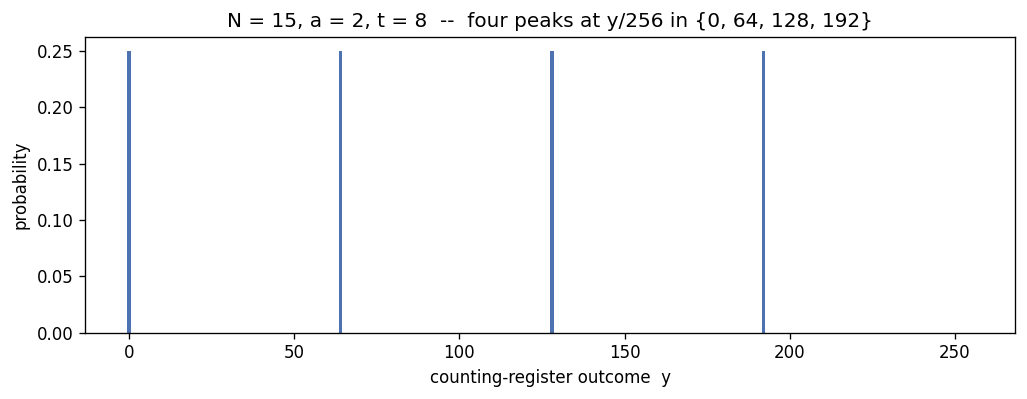

measured phases: ['0/256 = 0.000', '64/256 = 0.250', '128/256 = 0.500', '192/256 = 0.750']


In [ ]:
probs = order_finding_probs(N, a, t, use_swap_network=True)
y = np.arange(probs.size)
peaks = np.where(probs > 1e-6)[0]

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.bar(y, probs, width=1.0, color=COLORS[15])
ax.set_xlabel("counting-register outcome  y")
ax.set_ylabel("probability")
ax.set_title("N = 15, a = 2, t = 8  --  four peaks at y/256 in {0, 64, 128, 192}")
plt.show()

print("measured phases:", [f"{yy}/256 = {yy/256:.3f}" for yy in peaks])

In [ ]:
rows = []
for yy in peaks:
    theta = yy / 2**t
    r_est = phase_to_order(theta, N, a)
    fac = factor_from_phase(theta, N, a)
    rows.append([f"{yy}/256", f"{theta:.3f}", r_est, fac])
print(pd.DataFrame(rows, columns=["y", "theta", "estimated r", "factor of N"]).to_string(index=False))

      y theta  estimated r  factor of N
  0/256 0.000          NaN          NaN
 64/256 0.250          4.0          3.0
128/256 0.500          4.0          3.0
192/256 0.750          4.0          3.0


In [ ]:
p_swap = order_finding_probs(15, 2, 8, use_swap_network=True)
p_unit = order_finding_probs(15, 2, 8, use_swap_network=False)
print("max |difference| between the two distributions:", np.abs(p_swap - p_unit).max())

max |difference| between the two distributions: 3.3409558876152446e-52


## **2. Factoring 15, 21, 35, 105**

Base $a = 2$ for all of them (even order and $a^{r/2} \ne -1 \bmod N$, so the gcd
yields a factor). We use $t = 2n$ and show, for each $N$, the outcomes that lead
to a factor.

**Note:** $N = 15$ has $r = 4$ (a power of 2), so $k/4$ is representable
*exactly* in 2 bits: this is the lucky case of the tutorials. $N = 21, 35, 105$
have $r \in \{6, 12\}$, phases that are not finite binary fractions: here we
really need $\sim 2n$ qubits.

For $N=105$ the algorithm returns **one** non-trivial factor (e.g.
$105 = 5 \times 21$); the others follow by recursion. The success probability
$\ge 1 - 2^{-(k-1)}$ improves with the number $k$ of distinct
prime factors ($k=3$ for $105$).

In [ ]:
for N, a in [(15, 2), (21, 2), (35, 2), (105, 2)]:
    n = n_target_qubits(N); r = multiplicative_order(a, N); t = 2 * n
    probs = order_finding_probs(N, a, t)
    phases = np.arange(probs.size) / probs.size
    good = [(p, factor_from_phase(p, N, a)) for p in phases]
    good = [(p, f) for p, f in good if f is not None]
    p_succ = sum(probs[int(round(p * probs.size))] for p, _ in good)
    factors = sorted({f for _, f in good} | {N // f for _, f in good})
    print(f"N={N:3d} (n={n}, r={r:2d}, t={t:2d}):  "
          f"P[factor in 1 shot] = {p_succ:.3f},  factors found: {factors}  "
          f"->  {N} = {factors[0]} x {N // factors[0]}")

N= 15 (n=4, r= 4, t= 8):  P[factor in 1 shot] = 0.750,  factors found: [3, 5]  ->  15 = 3 x 5
N= 21 (n=5, r= 6, t=10):  P[factor in 1 shot] = 0.817,  factors found: [3, 7]  ->  21 = 3 x 7
N= 35 (n=6, r=12, t=12):  P[factor in 1 shot] = 0.905,  factors found: [5, 7]  ->  35 = 5 x 7
N=105 (n=7, r=12, t=14):  P[factor in 1 shot] = 0.907,  factors found: [5, 21]  ->  105 = 5 x 21


## **3. Experiment: spatial cost of the QPE register**

Sweep `t` from 2 to $2n+3$ (up to $2n+1$ for $N=105$, which already uses 22
qubits at $t=15$). For every `(N, t)` we run the circuit in analytic mode (no
shots) and compute all metrics with `analyse(...)`.

> The $N = 105$ rows at large $t$ simulate 20-22 qubits; the whole sweep takes a
> few minutes.

In [ ]:
TARGETS = [(15, 2), (21, 2), (35, 2), (105, 2)]

def t_values(N):
    n = n_target_qubits(N)
    return list(range(2, (2 * n + 3 if N < 100 else 2 * n + 1) + 1))

records = []
for N, a in TARGETS:
    for t in t_values(N):
        records.append(analyse(N, a, t).as_dict())
    print(f"N={N} done")
df = pd.DataFrame(records)
df.to_csv("sweep_results.csv", index=False)
df.head()

N=15 done
N=21 done
N=35 done
N=105 done


,N,a,r,n,t,width,n_ctrl_mult,n_ctrl_mult_nontrivial,qft_ctrl_phase,p_resolve,p_resolve_worstcase,p_factor,expected_shots
0,15,2,4,4,2,6,2,2,1,1.0,1.0,0.75,1.333333
1,15,2,4,4,3,7,3,2,3,1.0,1.0,0.75,1.333333
2,15,2,4,4,4,8,4,2,6,1.0,1.0,0.75,1.333333
3,15,2,4,4,5,9,5,2,10,1.0,1.0,0.75,1.333333
4,15,2,4,4,6,10,6,2,15,1.0,1.0,0.75,1.333333


### **3.1  Success vs register size**

For each $N$: $P_{\text{resolve}}$ (circles) and $P_{\text{factor}}$ (squares)
against `t`. Dotted grey line: worst-case bound $t = 2n+1$. Dashed black line:
the single-instance requirement $t \approx 2\log_2 r$.

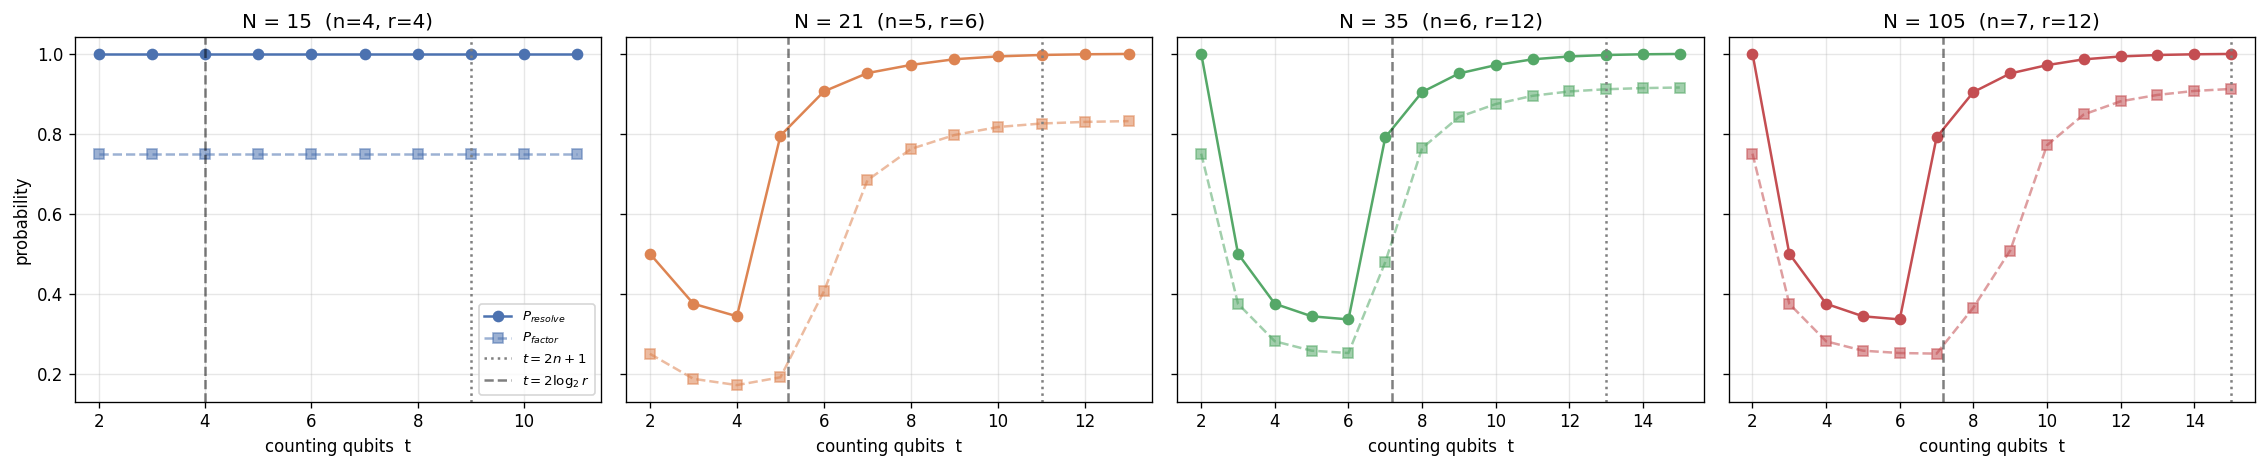

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4), sharey=True)
for ax, (N, _) in zip(axes, TARGETS):
    s = df[df.N == N].sort_values("t"); n = s.n.iloc[0]; r = s.r.iloc[0]
    ax.plot(s.t, s.p_resolve, "o-", color=COLORS[N], label=r"$P_{resolve}$")
    ax.plot(s.t, s.p_factor, "s--", color=COLORS[N], alpha=0.55, label=r"$P_{factor}$")
    ax.axvline(2 * n + 1, color="grey", ls=":", label=r"$t=2n+1$")
    ax.axvline(2 * np.log2(r), color="black", ls="--", alpha=0.5, label=r"$t=2\log_2 r$")
    ax.set_title(f"N = {N}  (n={n}, r={r})"); ax.set_xlabel("counting qubits  t"); ax.grid(alpha=.3)
axes[0].set_ylabel("probability"); axes[0].legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

**The non-monotonic dip at small $t$.** For $N=35,105$ the curve starts high
($t=2,3$), collapses ($t=4$-$6$) and recovers ($t \gtrsim 2\log_2 r$). This is
not a bug: with tiny $t$ the **only** representable phase values are $y/2^t$, and
when $2^t \mid r$ (here $r=12$, divisible by $4=2^2$) they coincide by *aliasing*
with true $k/r$. It is the same reason $N=15$ ($r=4$) "always works". As soon as
$t$ is large enough to sample phases $y/2^t$ that are **not** $k/r$ but not large
enough to resolve them, success collapses. The reliable regime is
$t \gtrsim 2\log_2 r$, and the worst-case bound valid for any $r<N$ is $t \ge 2n+1$.

### **3.2  Number of repetitions**

$E[\text{repetitions}] \approx 1/P_{\text{factor}}$. With few counting qubits you
need several times more; for $r$ close to $N$ (not the case for these small
instances) the factor $1/P_{\text{factor}}$ diverges.

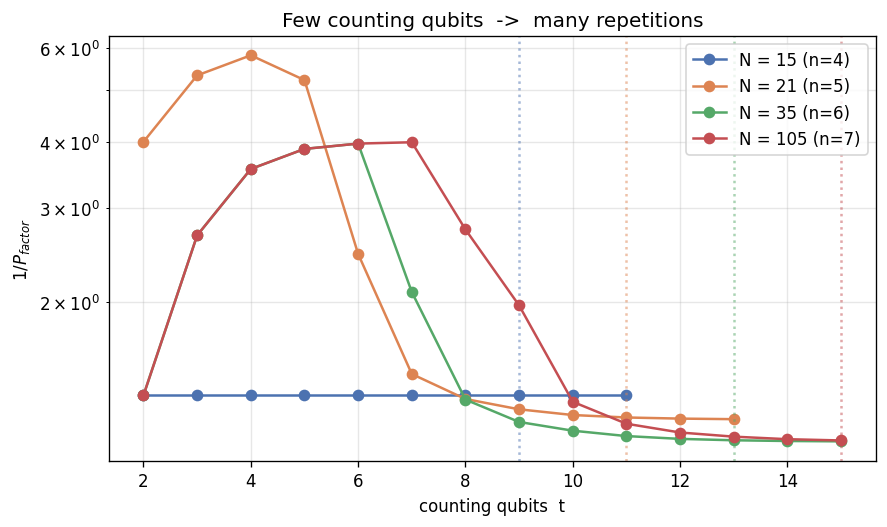

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for N, _ in TARGETS:
    s = df[df.N == N].sort_values("t"); n = s.n.iloc[0]
    ax.semilogy(s.t, s.expected_shots.clip(upper=1e6), "o-", color=COLORS[N],
                label=f"N = {N} (n={n})")
    ax.axvline(2 * n + 1, color=COLORS[N], ls=":", alpha=0.5)
ax.set_xlabel("counting qubits  t"); ax.set_ylabel(r"$1/P_{factor}$")
ax.set_title("Few counting qubits  ->  many repetitions"); ax.grid(alpha=.3, which="both")
ax.legend(); plt.tight_layout(); plt.show()

### **3.3  Distribution over the counting register ($N = 21$)**

The peaks go from broad and misplaced to sharp and centred on $k/6$ only as `t`
grows.

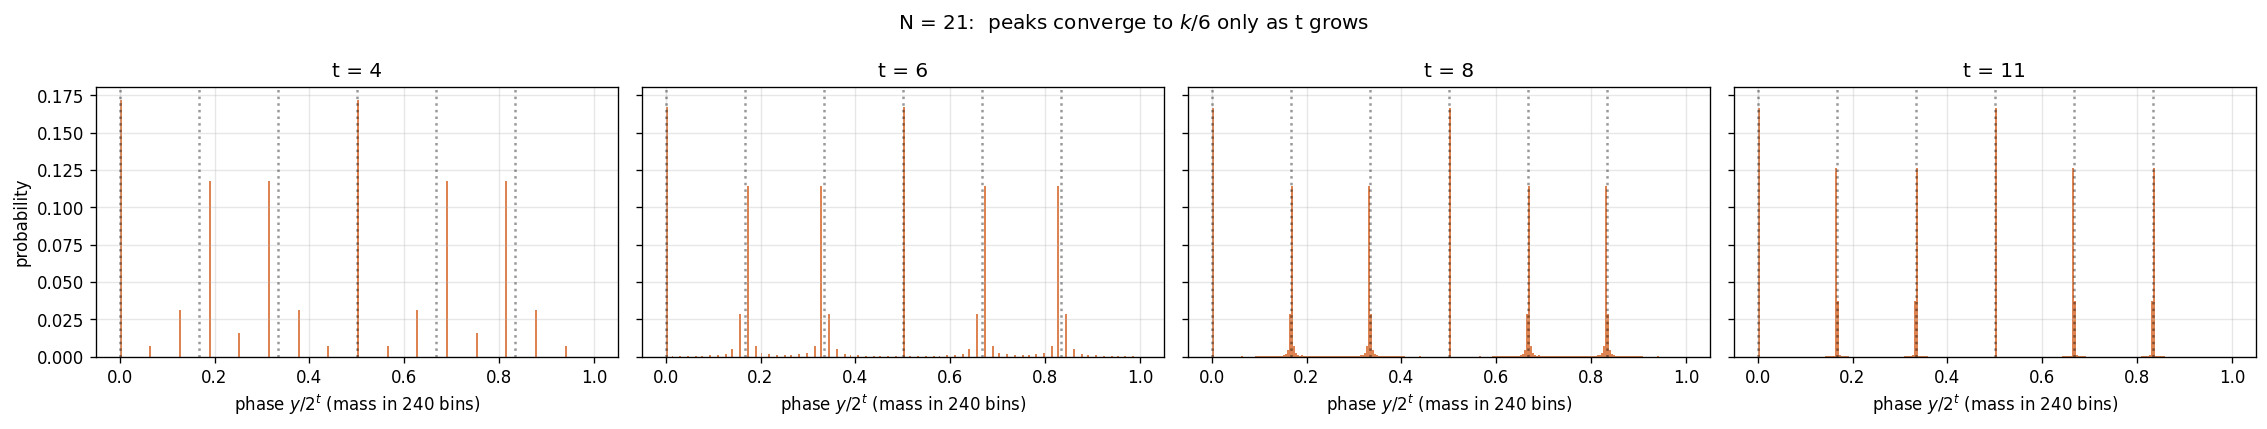

In [ ]:
edges = np.linspace(0, 1, 241); ctr = 0.5 * (edges[:-1] + edges[1:])
fig, axes = plt.subplots(1, 4, figsize=(19, 3.6), sharey=True)
for ax, t in zip(axes, [4, 6, 8, 11]):
    p = order_finding_probs(21, 2, t); ph = np.arange(p.size) / p.size
    binned, _ = np.histogram(ph, bins=edges, weights=p)
    ax.bar(ctr, binned, width=1 / 240, color=COLORS[21])
    for k in range(6):
        ax.axvline(k / 6, color="black", ls=":", alpha=0.4)
    ax.set_title(f"t = {t}"); ax.set_xlabel(r"phase $y/2^t$ (mass in 240 bins)"); ax.grid(alpha=.3)
axes[0].set_ylabel("probability")
fig.suptitle(r"N = 21:  peaks converge to $k/6$ only as t grows")
plt.tight_layout(); plt.show()

### **3.4  Circuit width**

`t*` = smallest `t` reaching 90% of the $P_{\text{factor}}$ asymptote.

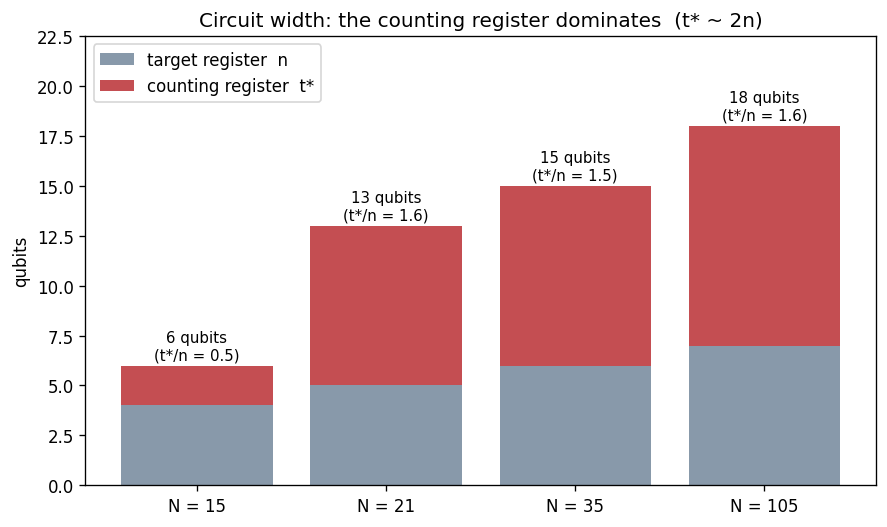

In [ ]:
def t_star(N, frac=0.9):
    s = df[df.N == N].sort_values("t"); thr = frac * s.p_factor.max()
    ok = s[s.p_factor >= thr]
    return int(ok.t.iloc[0]) if len(ok) else int(s.t.iloc[-1])

Ns = [N for N, _ in TARGETS]
n_arr = np.array([df[df.N == N].n.iloc[0] for N in Ns])
ts = np.array([t_star(N) for N in Ns])
x = np.arange(len(Ns))

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.bar(x, n_arr, label="target register  n", color="#8899AA")
ax.bar(x, ts, bottom=n_arr, label="counting register  t*", color="#C44E52")
for xi, ni, ti in zip(x, n_arr, ts):
    ax.text(xi, ni + ti + 0.3, f"{ni+ti} qubits\n(t*/n = {ti/ni:.1f})", ha="center", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([f"N = {N}" for N in Ns]); ax.set_ylabel("qubits")
ax.set_ylim(0, float((n_arr + ts).max()) + 4.5)
ax.set_title("Circuit width: the counting register dominates  (t* ~ 2n)")
ax.legend(loc="upper left"); plt.tight_layout(); plt.show()

### **3.5  Linear cost (width) vs quadratic cost (QFT$^{-1}$)**

The width $t+n$ grows **linearly**; the controlled-phase gates of the inverse
QFT, $t(t-1)/2$, grow **quadratically**.

The controlled modular multiplications are always $t$. The count of the
*non-trivial* ones (table below) shows two regimes: for $N=15$ it saturates at
**2** (for $j \ge 2$ we have $2^{2^j} \equiv 1 \bmod 15$ because $r=4$ divides
$2^j$, so $M_b = \mathbb{1}$ -- this is what the IBM tutorial exploits to skip
them); for $N=21,35,105$ **all** $t$ are non-trivial. In every case, though, the
*distinct* values $b = a^{2^j}\bmod N$ are very few (the cycle of $2^j \bmod r$),
so only 2-4 different $M_b$ operators are synthesised and applied $t$ times.

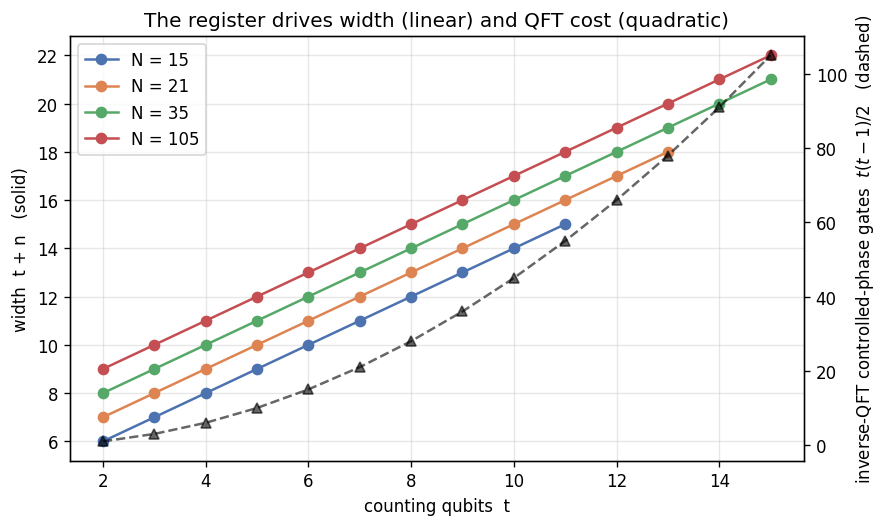

non-trivial modular multiplications (b != 1) vs t:
N   15    21    35    105
t                        
2   2.0   2.0   2.0   2.0
3   2.0   3.0   3.0   3.0
4   2.0   4.0   4.0   4.0
5   2.0   5.0   5.0   5.0
6   2.0   6.0   6.0   6.0
7   2.0   7.0   7.0   7.0
8   2.0   8.0   8.0   8.0
9   2.0   9.0   9.0   9.0
10  2.0  10.0  10.0  10.0
11  2.0  11.0  11.0  11.0
12  NaN  12.0  12.0  12.0
13  NaN  13.0  13.0  13.0
14  NaN   NaN  14.0  14.0
15  NaN   NaN  15.0  15.0

distinct values b = a^(2^j) mod N:
  N= 15: [1, 2, 4]   (sequence: [2, 4, 1, 1, 1, 1, 1, 1]...)
  N= 21: [2, 4, 16]   (sequence: [2, 4, 16, 4, 16, 4, 16, 4]...)
  N= 35: [2, 4, 11, 16]   (sequence: [2, 4, 16, 11, 16, 11, 16, 11]...)
  N=105: [2, 4, 16, 46]   (sequence: [2, 4, 16, 46, 16, 46, 16, 46]...)


In [ ]:
fig, ax1 = plt.subplots(figsize=(7.5, 4.5)); ax2 = ax1.twinx()
for N, _ in TARGETS:
    s = df[df.N == N].sort_values("t")
    ax1.plot(s.t, s.width, "o-", color=COLORS[N], label=f"N = {N}")
allt = np.array(sorted(df.t.unique()))
ax2.plot(allt, allt * (allt - 1) // 2, "^--", color="black", alpha=0.6)
ax1.set_xlabel("counting qubits  t"); ax1.set_ylabel("width  t + n   (solid)")
ax2.set_ylabel(r"inverse-QFT controlled-phase gates  $t(t-1)/2$   (dashed)")
ax1.set_title("The register drives width (linear) and QFT cost (quadratic)")
ax1.grid(alpha=.3); ax1.legend(); plt.tight_layout(); plt.show()

piv = df.pivot_table(index="t", columns="N", values="n_ctrl_mult_nontrivial")
print("non-trivial modular multiplications (b != 1) vs t:")
print(piv.to_string())

print("\ndistinct values b = a^(2^j) mod N:")
for N, a in TARGETS:
    tmax = int(df[df.N == N].t.max())
    bs = [pow(a, 1 << j, N) for j in range(tmax)]
    print(f"  N={N:3d}: {sorted(set(bs))}   (sequence: {bs[:8]}...)")

### **3.6  Summary table**

In [ ]:
rows = []
for N, a in TARGETS:
    s = df[df.N == N].sort_values("t"); n = s.n.iloc[0]; r = s.r.iloc[0]; ts = t_star(N)
    at2n = s[s.t == 2 * n]; atn = s[s.t == n]
    rows.append({
        "N": N, "a": a, "r": r, "n": n,
        "t* (emp.)": ts, "2n+1 (theory)": 2 * n + 1, "width @ t*": ts + n,
        "t*/n": round(ts / n, 2),
        "P_factor @ t=2n": round(float(at2n.p_factor.iloc[0]), 3) if len(at2n) else None,
        "E[shots] @ t=n": round(float(atn.expected_shots.iloc[0]), 1) if len(atn) else None,
    })
tbl = pd.DataFrame(rows); tbl.to_csv("summary_table.csv", index=False)
tbl

,N,a,r,n,t* (emp.),2n+1 (theory),width @ t*,t*/n,P_factor @ t=2n,E[shots] @ t=n
0,15,2,4,4,2,9,6,0.50,0.750,1.3
1,21,2,6,5,8,11,13,1.60,0.817,5.2
2,35,2,12,6,9,13,15,1.50,0.905,4.0
3,105,2,12,7,11,15,18,1.57,0.907,4.0


## **4. Conclusions**

**Measured spatial cost.** For the three non-degenerate instances the smallest
reliable counting register is

| $N$ | $n$ (target) | $t^*$ (counting) | total | $t^*/n$ |
|---|---|---|---|---|
| 21 | 5 | 8 | 13 | 1.6 |
| 35 | 6 | 9 | 15 | 1.5 |
| 105 | 7 | 11 | 18 | 1.57 |

i.e. $t^* \approx 1.5\text{--}1.6\,n$, consistent with the regime
$t \gtrsim 2\log_2 r$ (here $r\in\{6,12\}$, not $r\approx N$) and well within the
worst-case bound $t \le 2n+1$. **The register whose only job is to read the phase
is larger than the register that holds the number**, and the total width is
$\approx 2.5\text{--}2.6\,n$ (it would tend to $3n$ for $r$ close to $N$).

**$N = 15$ is misleading.** With $r = 4 = 2^2$ every phase $k/4$ is exact in
2 bits: $P_{\text{factor}} = 0.75$ already at $t = 2$. Tutorials that stop at
$N=15$ hide the cost of the QPE register.

**Two different scalings in the same circuit.** As `t` grows: the width $t+n$
grows **linearly**; the inverse-QFT controlled-phase gates, $t(t-1)/2$,
**quadratically**. The $t$ modular multiplications use only 2-4 distinct $M_b$
operators (for $N=15$ the late ones collapse to $\mathbb{1}$; for $21,35,105$
they do not). The estimation register is therefore the bottleneck both in space
and (through the QFT) in depth.

**Towards RSA.** The width $\approx 3\log_2 N$ and the $\approx 2\log_2 N$
controlled modular multiplications, extrapolated to $N \sim 2^{2048}$, give
thousands of logical qubits *just* for the two main registers -- before error
correction and before the ancillas of a general modular multiplier (which, for a
generic $N$, not chosen as here, costs $\sim 2n$ extra ancilla qubits). This is
the origin of the "millions of physical qubits" estimate quoted at the end of the
IBM tutorial.